<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; line-height:2; background:#e8eaf6; border-right:6px solid #3949ab; padding:20px 24px; margin:10px 0; border-radius:8px;">

<h2 style="color:#1a237e;">تجزئة الصور باستخدام K-Means — (اللون + الموضع)</h2>

<p>يهدف هذا الدفتر إلى تطبيق <strong>تجزئة الصور (Image Segmentation)</strong> باستخدام خوارزمية <strong>K-Means Clustering</strong>، حيث يُمثَّل كل بكسل في الصورة بمتجه ميزات يجمع بين <strong>موضعه</strong> و<strong>لونه</strong>.</p>

<p><strong>الفكرة الأساسية:</strong> البكسلات المتشابهة في اللون والقريبة مكانياً تنتمي إلى نفس المجموعة، مما يُنتج مناطق متماسكة بصرياً تُمثّل أجزاء الصورة.</p>

<table style="width:100%; border-collapse:collapse; text-align:right; direction:rtl; margin-top:10px;">
  <tr style="background:#c5cae9;">
    <th style="padding:8px; border:1px solid #9fa8da;">الخطوة</th>
    <th style="padding:8px; border:1px solid #9fa8da;">الوصف</th>
  </tr>
  <tr><td style="padding:8px; border:1px solid #9fa8da;">1</td><td style="padding:8px; border:1px solid #9fa8da;">قراءة الصورة وتحويلها إلى RGB وتصغيرها</td></tr>
  <tr><td style="padding:8px; border:1px solid #9fa8da;">2</td><td style="padding:8px; border:1px solid #9fa8da;">بناء متجه ميزات لكل بكسل (5 ميزات: X، Y، R، G، B)</td></tr>
  <tr><td style="padding:8px; border:1px solid #9fa8da;">3</td><td style="padding:8px; border:1px solid #9fa8da;">تطبيق K-Means للتجميع إلى K مجموعات</td></tr>
  <tr><td style="padding:8px; border:1px solid #9fa8da;">4</td><td style="padding:8px; border:1px solid #9fa8da;">عرض النتائج عبر Overlay شفاف ملون</td></tr>
</table>

</div>

In [141]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:15px; line-height:1.9; background:#f1f8e9; border-right:5px solid #388e3c; padding:16px 20px; margin:8px 0; border-radius:7px;">

<h3 style="color:#1b5e20;">المكتبات المستخدمة</h3>
<ul>
  <li><strong>cv2 (OpenCV):</strong> قراءة الصور، تحويل فضاء الألوان (BGR ← RGB)، وتغيير الحجم</li>
  <li><strong>numpy:</strong> العمليات الحسابية الفعّالة على مصفوفات البكسلات وبناء Feature Matrix</li>
  <li><strong>matplotlib.pyplot:</strong> عرض الصور والنتائج البصرية داخل الدفتر</li>
  <li><strong>KMeans (sklearn):</strong> خوارزمية التجميع غير المراقب — تُقسّم البيانات إلى K مجموعات دون الحاجة إلى تسميات مسبقة (Labels)</li>
</ul>

</div>

In [145]:

# =========================
# قراءة الصورة
# =========================

IMAGE_PATH = "image.png"

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise Exception("لم يتم العثور على الصورة")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# تصغير الصورة لتسريع التنفيذ
image = cv2.resize(image, (300, 300))

height, width, _ = image.shape



In [154]:
image[2,0]

array([ 38, 103, 176], dtype=uint8)

<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:15px; line-height:1.9; background:#e3f2fd; border-right:5px solid #1565c0; padding:16px 20px; margin:8px 0; border-radius:7px;">

<h3 style="color:#0d47a1;">قراءة الصورة وتجهيزها</h3>
<ul>
  <li><code>cv2.imread</code> تقرأ الصورة من القرص بفضاء <strong>BGR</strong> (الترتيب الافتراضي في OpenCV)</li>
  <li><code>cvtColor(BGR → RGB)</code> تُحوّل الصورة لأن matplotlib يعرض الألوان بترتيب RGB — بدونها تظهر القناة الحمراء والزرقاء مقلوبتين</li>
  <li><code>cv2.resize(300, 300)</code> تُصغّر الصورة لتسريع التنفيذ — K-Means يعالج كل بكسل على حدة، لذا الصورة الأصغر تعني وقتاً أقل بكثير</li>
</ul>

</div>

In [158]:

# =========================
# بناء Feature Vector
# =========================

features = []

for y in range(height):
    for x in range(width):

        r, g, b = image[y, x]

        feature_vector = [
            x / width,     # Normalize X
            y / height,    # Normalize Y
            r / 255.0,
            g / 255.0,
            b / 255.0
        ]

        features.append(feature_vector)

features = np.array(features)

print("Feature matrix shape:", features.shape)

features

Feature matrix shape: (90000, 5)


array([[0.        , 0.        , 0.14117647, 0.39607843, 0.69019608],
       [0.00333333, 0.        , 0.14117647, 0.4       , 0.69803922],
       [0.00666667, 0.        , 0.14509804, 0.4       , 0.69803922],
       ...,
       [0.99      , 0.99666667, 0.44705882, 0.27843137, 0.11764706],
       [0.99333333, 0.99666667, 0.5372549 , 0.37647059, 0.2       ],
       [0.99666667, 0.99666667, 0.44313725, 0.29803922, 0.14117647]])

In [160]:
features

array([[0.        , 0.        , 0.14117647, 0.39607843, 0.69019608],
       [0.00333333, 0.        , 0.14117647, 0.4       , 0.69803922],
       [0.00666667, 0.        , 0.14509804, 0.4       , 0.69803922],
       ...,
       [0.99      , 0.99666667, 0.44705882, 0.27843137, 0.11764706],
       [0.99333333, 0.99666667, 0.5372549 , 0.37647059, 0.2       ],
       [0.99666667, 0.99666667, 0.44313725, 0.29803922, 0.14117647]])

<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:15px; line-height:1.9; background:#fff3e0; border-right:5px solid #e65100; padding:16px 20px; margin:8px 0; border-radius:7px;">

<h3 style="color:#bf360c;">بناء متجه الميزات (Feature Vector)</h3>
<p>لكل بكسل في الصورة نبني متجهاً من <strong>5 ميزات مُطبَّعة</strong> في النطاق [0, 1]:</p>

<table style="width:100%; border-collapse:collapse; text-align:right; direction:rtl;">
  <tr style="background:#ffe0b2;">
    <th style="padding:7px; border:1px solid #ffb74d;">الميزة</th>
    <th style="padding:7px; border:1px solid #ffb74d;">المعنى</th>
    <th style="padding:7px; border:1px solid #ffb74d;">التطبيع</th>
  </tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;"><code>x / width</code></td><td style="padding:7px; border:1px solid #ffb74d;">الموضع الأفقي</td><td style="padding:7px; border:1px solid #ffb74d;">÷ عرض الصورة</td></tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;"><code>y / height</code></td><td style="padding:7px; border:1px solid #ffb74d;">الموضع الرأسي</td><td style="padding:7px; border:1px solid #ffb74d;">÷ ارتفاع الصورة</td></tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;"><code>r / 255</code></td><td style="padding:7px; border:1px solid #ffb74d;">شدة اللون الأحمر</td><td style="padding:7px; border:1px solid #ffb74d;">÷ 255</td></tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;"><code>g / 255</code></td><td style="padding:7px; border:1px solid #ffb74d;">شدة اللون الأخضر</td><td style="padding:7px; border:1px solid #ffb74d;">÷ 255</td></tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;"><code>b / 255</code></td><td style="padding:7px; border:1px solid #ffb74d;">شدة اللون الأزرق</td><td style="padding:7px; border:1px solid #ffb74d;">÷ 255</td></tr>
</table>

<p style="margin-top:10px;">الناتج النهائي: مصفوفة شكلها <code>(90000, 5)</code> حيث 90000 = 300 × 300 بكسل.</p>
<p><strong>لماذا ندمج الموضع مع اللون؟</strong> لأن K-Means وحده قد يُجمّع بكسلات بعيدة مكانياً إذا كانت متشابهة في اللون — إضافة الموضع تُرغمه على أن تكون المجموعات متجاورة أيضاً.</p>

</div>

In [205]:

# =========================
# تطبيق K-Means
# =========================

K = 20

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(features)

print("Clustering completed")


Clustering completed


In [206]:
len(labels)

90000

In [207]:
labels[80000:80100]

array([17,  4,  4,  4,  4, 17,  4,  4,  8,  4, 17, 17,  4,  4,  4,  4,  4,
       17,  4,  4,  4,  4,  4,  4,  4, 13,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4, 13,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4, 13, 13,  4,
        4,  4, 13,  4,  4,  4,  8,  4, 13,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4])

<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:15px; line-height:1.9; background:#f3e5f5; border-right:5px solid #6a1b9a; padding:16px 20px; margin:8px 0; border-radius:7px;">

<h3 style="color:#4a148c;">خوارزمية K-Means — كيف تعمل؟</h3>

<p>K-Means خوارزمية تكرارية تُقسّم البيانات إلى <strong>K مجموعات (Clusters)</strong> عبر الخطوات التالية:</p>
<ol>
  <li>تُختار K نقطة بداية عشوائية كمراكز أولية (Centroids)</li>
  <li>يُعيَّن كل بكسل للمجموعة الأقرب إليه (بمسافة إقليدية)</li>
  <li>تُحسَب مراكز جديدة كمتوسط بكسلات كل مجموعة</li>
  <li>تُكرَّر الخطوتان 2 و3 حتى تستقر المراكز</li>
</ol>

<table style="width:100%; border-collapse:collapse; text-align:right; direction:rtl; margin-top:10px;">
  <tr style="background:#e1bee7;">
    <th style="padding:7px; border:1px solid #ce93d8;">المعامل</th>
    <th style="padding:7px; border:1px solid #ce93d8;">القيمة</th>
    <th style="padding:7px; border:1px solid #ce93d8;">الهدف</th>
  </tr>
  <tr><td style="padding:7px; border:1px solid #ce93d8;"><code>n_clusters=5</code></td><td style="padding:7px; border:1px solid #ce93d8;">5</td><td style="padding:7px; border:1px solid #ce93d8;">تقسيم الصورة إلى 5 مناطق</td></tr>
  <tr><td style="padding:7px; border:1px solid #ce93d8;"><code>n_init=10</code></td><td style="padding:7px; border:1px solid #ce93d8;">10</td><td style="padding:7px; border:1px solid #ce93d8;">10 محاولات، أفضلها يُختار تلقائياً</td></tr>
  <tr><td style="padding:7px; border:1px solid #ce93d8;"><code>random_state=42</code></td><td style="padding:7px; border:1px solid #ce93d8;">42</td><td style="padding:7px; border:1px solid #ce93d8;">بذرة عشوائية للحصول على نفس النتائج</td></tr>
</table>

</div>

In [209]:

# =========================
# إعادة تشكيل Labels
# =========================

segmented = labels.reshape(height, width)
segmented.shape

(300, 300)

In [210]:
segmented[0]

array([ 7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
       15, 15, 15,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16,  9,  9,  9,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9

In [211]:


# =========================
# إنشاء Overlay شفاف
# =========================

# ألوان العناقيد
colors = np.array([
    [255, 0, 0],      # أحمر
    [0, 255, 0],      # أخضر
    [0, 0, 255],      # أزرق
    [255, 255, 0],    # أصفر
    [255, 0, 255],    # بنفسجي
     [100, 255, 1],
    [1, 255, 100]  ,  
[150, 255, 50]   , 
  [50, 50, 255]    ,
   [100, 20, 255] ,
        [100, 0, 100],      # أحمر
    [0, 100,100],      # أخضر
    [0, 120, 120],      # أزرق
    [50, 150, 0],    # أصفر
    [77, 0, 77],    # بنفسجي
     [100, 60, 1],
    [1, 50, 170]  ,  
[120, 100, 50]   , 
  [170, 0, 100]    ,
   [100, 200, 50]   

])
#    [100, 255, 1] ,   
#[1, 255, 100]  ,  
#[150, 255, 50]   , 
#  [50, 50, 255]    ,
#   [100, 20, 255]    ,
overlay = image.copy()

alpha = 0.35  # الشفافية

for cluster_id in range(K):

    mask = segmented == cluster_id

    color = colors[cluster_id % len(colors)]

    overlay[mask] = (
        (1 - alpha) * overlay[mask] +
        alpha * color
    ).astype(np.uint8)


<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:15px; line-height:1.9; background:#e0f7fa; border-right:5px solid #00838f; padding:16px 20px; margin:8px 0; border-radius:7px;">

<h3 style="color:#006064;">إنشاء الـ Overlay وعرض النتائج</h3>

<ul>
  <li><strong>إعادة التشكيل (Reshape):</strong> نُحوّل مصفوفة <code>labels</code> ذات البُعد الواحد <code>(90000,)</code> إلى خريطة ثنائية الأبعاد <code>(height, width)</code></li>
  <li><strong>تعيين الألوان:</strong> لكل مجموعة من 0 إلى 4 لون مميز: أحمر، أخضر، أزرق، أصفر، بنفسجي</li>
  <li><strong>مزج الألوان:</strong> المعادلة المستخدمة هي:
    <br><code>pixel_جديد = (1 − 0.35) × pixel_أصلي  +  0.35 × لون_المجموعة</code>
    <br>أي أن 65% من الصورة الأصلية تظهر مع 35% من اللون الدلالي للمجموعة</li>
</ul>

<p><strong>الناتج:</strong> صورتان جنباً إلى جنب — الصورة الأصلية والصورة مع طبقة التجزئة الملونة الشفافة.</p>

</div>

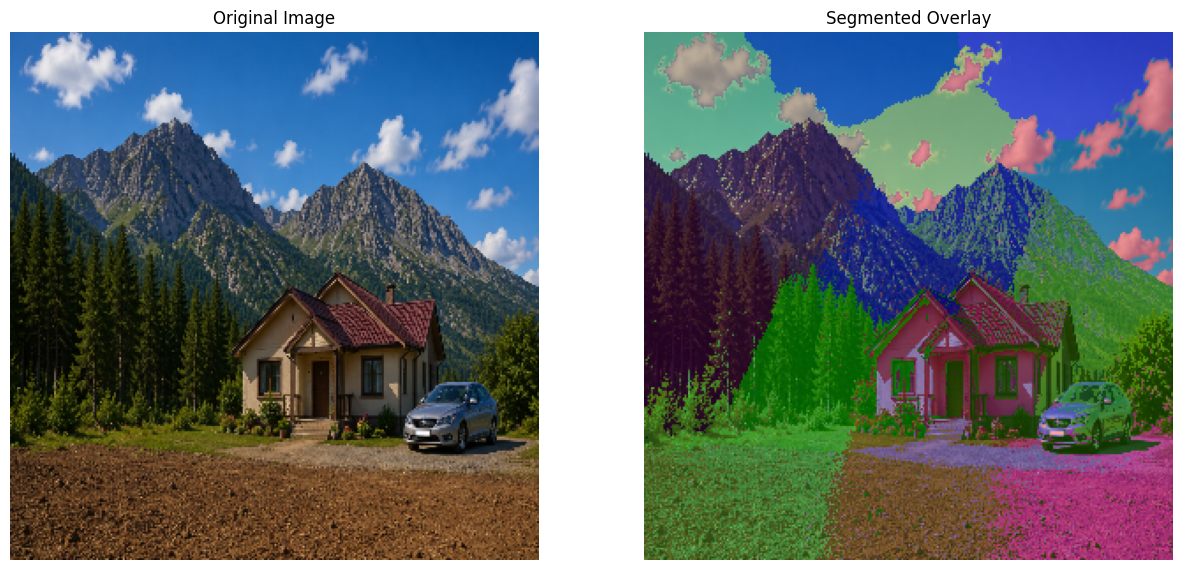

In [213]:


# =========================
# عرض النتائج
# =========================

plt.figure(figsize=(15, 7))

# الصورة الأصلية
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# الصورة مع الطبقة الشفافة
plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title("Segmented Overlay")
plt.axis("off")

plt.show()